<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day04-alignment-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 4 — Sequence Alignment in code

This notebook implements Needleman-Wunsch (global) and Smith-Waterman (local) alignment from scratch, using **amino-acid** sequences and a simple identity scoring scheme (a match scores +1, any mismatch −1, any gap −1 — equivalent to using the identity matrix as the substitution matrix; PAM/BLOSUM are covered conceptually on the Day 4 page itself and aren't needed here). Rather than jumping straight to a finished matrix, this notebook builds the small worked example up **cell by cell with the reasoning printed out**, gives you a **partially-filled matrix to complete yourself** before revealing the real one, and walks the **traceback** the same step-by-step way — so both halves of the algorithm (filling forward, then reading back) are shown as a sequence of small decisions rather than as a finished picture.

The core algorithm functions below are adapted from Lukas Käll's open-access bioinformatics textbook, [*bibook*](https://github.com/statisticalbiotechnology/bibook) (`bibook/pairwise/nw_code.ipynb` and `sw_code.ipynb`), licensed [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). The step-by-step construction, the fill-it-yourself exercise, the traceback walkthrough, and the visualization are original to this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Adapted from bibook (Käll, CC BY 4.0): bibook/pairwise/nw_code.ipynb, sw_code.ipynb

def format_alignment(seqA, seqB, S, trace):
    """Traceback from the bottom-right corner to the top-left (global alignment)."""
    outA, outB = "", ""
    i, j = len(seqA), len(seqB)
    while i > 0 or j > 0:
        di, dj = trace[i, j]
        i += int(di)
        j += int(dj)
        outA = ("-" if di == 0 else seqA[i]) + outA
        outB = ("-" if dj == 0 else seqB[j]) + outB
    return outA, outB


def format_local_alignment(seqA, seqB, S, trace):
    """Traceback from the highest-scoring cell until a 0 is hit (local alignment)."""
    outA, outB = "", ""
    i, j = np.unravel_index(S.argmax(), S.shape)
    while min(trace[i, j]) < 0:
        di, dj = trace[i, j]
        i += int(di)
        j += int(dj)
        outA = ("-" if di == 0 else seqA[i]) + outA
        outB = ("-" if dj == 0 else seqB[j]) + outB
    return outA, outB

## Needleman-Wunsch (global alignment)

In [2]:
def global_align(seqA, seqB, match=1.0, mismatch=-1.0, gap=-1.0, subst_matrix=None):
    def score(a, b):
        if a == '-' or b == '-':
            return gap
        if subst_matrix is not None:
            return subst_matrix[a, b]
        return match if a == b else mismatch

    m, n = len(seqA) + 1, len(seqB) + 1
    S = np.zeros((m, n))
    trace = np.zeros((m, n, 2))
    for i in range(1, m):
        S[i, 0] = i * gap
        trace[i, 0, :] = (-1, 0)
    for j in range(1, n):
        S[0, j] = j * gap
        trace[0, j, :] = (0, -1)

    for i in range(1, m):
        for j in range(1, n):
            diag = S[i-1, j-1] + score(seqA[i-1], seqB[j-1])
            up = S[i-1, j] + gap
            left = S[i, j-1] + gap
            S[i, j] = max(diag, up, left)
            if diag >= max(up, left):
                trace[i, j, :] = (-1, -1)
            elif up >= left:
                trace[i, j, :] = (-1, 0)
            else:
                trace[i, j, :] = (0, -1)
    return S, trace

### A small worked example, step by step

`VHLT` is a real 4-residue fragment of human beta-globin (HBB, positions 2-5 — the same protein used as the running example on Days 3 and 5). `VLC` is a hypothetical mutated variant of it, 3 residues long, with the H deleted and the final T substituted by C — small enough to fill in completely by hand, and rigged to need all three kinds of move (a match, a gap, and a mismatch), just like the Day 4 page's own worked example.

Rather than jumping straight to the finished matrix, the cell below fills it in **one cell at a time**, printing the three candidate scores (diagonal match/mismatch, up gap, left gap) and which one won, exactly as the recurrence

$$
V(i,j) = \max \begin{cases} V(i-1,j-1) + s(x_i, y_j) \\ V(i-1,j) + g \\ V(i,j-1) + g \end{cases}
$$

is applied in practice.

In [3]:
seqA, seqB = "VHLT", "VLC"
match, mismatch, gap = 1.0, -1.0, -1.0

def score(a, b):
    if a == '-' or b == '-':
        return gap
    return match if a == b else mismatch

m, n = len(seqA) + 1, len(seqB) + 1
S = np.full((m, n), np.nan)
trace = np.zeros((m, n, 2))

print(f"Aligning seqA = {seqA!r} against seqB = {seqB!r}")
print(f"match = {match}, mismatch = {mismatch}, gap = {gap}")
print()

S[0, 0] = 0.0
print("S[0,0] = 0   (both sequences empty)")
for i in range(1, m):
    S[i, 0] = i * gap
    trace[i, 0, :] = (-1, 0)
    print(f"S[{i},0] = {i} x gap = {S[i,0]:.0f}   ({seqA[:i]!r} vs nothing: {i} gap(s))")
for j in range(1, n):
    S[0, j] = j * gap
    trace[0, j, :] = (0, -1)
    print(f"S[0,{j}] = {j} x gap = {S[0,j]:.0f}   (nothing vs {seqB[:j]!r}: {j} gap(s))")

print()
print("Border filled in. So far:")
print(S)
print()
print("Now the interior, one cell at a time:")
print()

for i in range(1, m):
    for j in range(1, n):
        diag = S[i-1, j-1] + score(seqA[i-1], seqB[j-1])
        up = S[i-1, j] + gap
        left = S[i, j-1] + gap
        best = max(diag, up, left)
        S[i, j] = best
        if diag >= max(up, left):
            trace[i, j, :] = (-1, -1)
            move = "diagonal"
        elif up >= left:
            trace[i, j, :] = (-1, 0)
            move = "up"
        else:
            trace[i, j, :] = (0, -1)
            move = "left"
        kind = "match" if seqA[i-1] == seqB[j-1] else "mismatch"
        print(f"S[{i},{j}]: {seqA[i-1]} vs {seqB[j-1]} ({kind}) "
              f"-> diag={diag:.0f}, up={up:.0f}, left={left:.0f}  =>  max = {best:.0f}  ({move})")
    print(f"  -- row {i} complete: {S[i]}")
    print()

print("Completed matrix:")
print(S)

Aligning seqA = 'VHLT' against seqB = 'VLC'
match = 1.0, mismatch = -1.0, gap = -1.0

S[0,0] = 0   (both sequences empty)
S[1,0] = 1 x gap = -1   ('V' vs nothing: 1 gap(s))
S[2,0] = 2 x gap = -2   ('VH' vs nothing: 2 gap(s))
S[3,0] = 3 x gap = -3   ('VHL' vs nothing: 3 gap(s))
S[4,0] = 4 x gap = -4   ('VHLT' vs nothing: 4 gap(s))
S[0,1] = 1 x gap = -1   (nothing vs 'V': 1 gap(s))
S[0,2] = 2 x gap = -2   (nothing vs 'VL': 2 gap(s))
S[0,3] = 3 x gap = -3   (nothing vs 'VLC': 3 gap(s))

Border filled in. So far:
[[ 0. -1. -2. -3.]
 [-1. nan nan nan]
 [-2. nan nan nan]
 [-3. nan nan nan]
 [-4. nan nan nan]]

Now the interior, one cell at a time:

S[1,1]: V vs V (match) -> diag=1, up=-2, left=-2  =>  max = 1  (diagonal)
S[1,2]: V vs L (mismatch) -> diag=-2, up=-3, left=0  =>  max = 0  (left)
S[1,3]: V vs C (mismatch) -> diag=-3, up=-4, left=-1  =>  max = -1  (left)
  -- row 1 complete: [-1.  1.  0. -1.]

S[2,1]: H vs V (mismatch) -> diag=-2, up=0, left=-3  =>  max = 0  (up)
S[2,2]: H vs L (

### Now you try: fill in the matrix yourself

Below is the same matrix with a handful of interior cells blanked out (`nan`). Using the same rule as above — the max of the diagonal (match/mismatch), up (gap), and left (gap) candidates — work out what each blanked cell should be, either by hand or on paper, and write your answers into `your_guesses` in the next cell. Then run the check cell after it to see whether you got them right; if not, look at that cell's neighbours in the printed matrix above and try again.

In [4]:
blanked_cells = [(2, 2), (2, 3), (3, 1), (3, 2), (4, 2), (4, 3)]

puzzle = S.copy()
for (i, j) in blanked_cells:
    puzzle[i, j] = np.nan

print("Rows = '-' + seqA, columns = '-' + seqB:")
print("        " + "     ".join(["-"] + list(seqB)))
for i, row_label in enumerate(["-"] + list(seqA)):
    print(row_label, puzzle[i])
print()
print(f"Blanked cells to work out: {blanked_cells}")

Rows = '-' + seqA, columns = '-' + seqB:
        -     V     L     C
- [ 0. -1. -2. -3.]
V [-1.  1.  0. -1.]
H [-2.  0. nan nan]
L [-3. nan nan  0.]
T [-4. -2. nan nan]

Blanked cells to work out: [(2, 2), (2, 3), (3, 1), (3, 2), (4, 2), (4, 3)]


In [5]:
# Replace each None with the value you worked out for that cell.
your_guesses = {
    (2, 2): None,
    (2, 3): None,
    (3, 1): None,
    (3, 2): None,
    (4, 2): None,
    (4, 3): None,
}

print("Checking your guesses against the real matrix:")
print()
all_correct = True
for (i, j), guess in your_guesses.items():
    real = S[i, j]
    if guess is None:
        print(f"  S[{i},{j}]: not filled in yet (real value is {real:.0f})")
        all_correct = False
    elif float(guess) == real:
        print(f"  S[{i},{j}]: correct! ({real:.0f})")
    else:
        print(f"  S[{i},{j}]: your guess {guess} does not match the real value {real:.0f}")
        all_correct = False

print()
print("All correct -- you've got the recurrence." if all_correct
      else "Fill in every value above (or fix any mismatches) and re-run this cell.")

Checking your guesses against the real matrix:

  S[2,2]: not filled in yet (real value is 0)
  S[2,3]: not filled in yet (real value is -1)
  S[3,1]: not filled in yet (real value is -1)
  S[3,2]: not filled in yet (real value is 1)
  S[4,2]: not filled in yet (real value is 0)
  S[4,3]: not filled in yet (real value is 0)

Fill in every value above (or fix any mismatches) and re-run this cell.


### The reveal: full matrix and alignment

In [6]:
print("The full computed matrix:")
print(S)
print()

outA, outB = format_alignment(seqA, seqB, S, trace)
print("Alignment:")
print(outA)
print(outB)
print("Score:", S[-1, -1])

The full computed matrix:
[[ 0. -1. -2. -3.]
 [-1.  1.  0. -1.]
 [-2.  0.  0. -1.]
 [-3. -1.  1.  0.]
 [-4. -2.  0.  0.]]

Alignment:
VHLT
V-LC
Score: 0.0


### Real substitution matrices: PAM250

Every alignment so far used a **flat identity scheme**: any matching pair of residues scores $+1$, any mismatching pair scores $-1$, no matter *which* residues they are. Real alignment tools don't do this — they use substitution matrices like the **PAM** and **BLOSUM** families introduced earlier on the Day 4 page, built from real observed substitution frequencies, because not every substitution is equally likely or equally disruptive: swapping a leucine for a similar isoleucine happens all the time and barely changes a protein's structure, while swapping it for a proline (which breaks helices) is rare and consequential.

Below is the real **PAM250** matrix (Dayhoff, Schwartz & Orcutt, 1978), loaded from Biopython rather than typed in by hand, compared directly against the flat identity scheme used so far:

In [7]:
from Bio.Align import substitution_matrices

pam250 = substitution_matrices.load("PAM250")

print(f"{'pair':6}{'identity':>10}{'PAM250':>10}")
for a, b in [("L", "L"), ("L", "I"), ("L", "P"), ("W", "W"), ("W", "Y"), ("W", "D"), ("K", "R"), ("K", "D")]:
    ident = 1.0 if a == b else -1.0
    print(f"{a}-{b:<4}{ident:>+10.0f}{pam250[a, b]:>+10.0f}")

pair    identity    PAM250
L-L           +1        +6
L-I           -1        +2
L-P           -1        -3
W-W           +1       +17
W-Y           -1        +0
W-D           -1        -7
K-R           -1        +3
K-D           -1        +0


Two things to notice: PAM250 still rewards an exact match more than any substitution (`L`-`L` scores $+6$, higher than any `L`-X substitution), but *unlike* the flat scheme, not every mismatch costs the same. `L`-`I` (both branched hydrophobic residues) scores $+2$ — better than the flat $-1$, because that substitution is biologically mild and evolutionarily common. `L`-`P` scores $-3$ — worse than the flat $-1$, because proline's rigid ring breaks the local structure a leucine would normally support. Same story for `K`-`R` (+3, both positively charged) versus `W`-`D` (-7, about as different as two residues get).

This graded scoring is exactly why real tools use PAM/BLOSUM instead of a flat penalty. The small-example traceback walkthrough right after this keeps using the identity scheme, so the arithmetic stays easy to follow by hand — but the final Needleman-Wunsch/Smith-Waterman example further below switches to this real PAM250 matrix instead, by generalizing `global_align` and `local_align` (defined above) to accept an optional substitution matrix in place of `match`/`mismatch`.

### Tracing back, step by step

Filling the matrix only gives the *best score* — the alignment itself comes from **tracing back** through the choices that were made along the way, starting at the bottom-right corner (for a global alignment) and following each cell's winning move back to the top-left. The function below walks that path one step at a time, re-showing the same three candidates that were computed while filling the matrix, so it's clear *why* each step goes the direction it does — building the aligned strings up from the end backwards, rather than presenting them ready-made.

In [8]:
def verbose_traceback(seqA, seqB, S, trace, gap, match=1.0, mismatch=-1.0, subst_matrix=None, global_alignment=True):
    """Walk the traceback path one step at a time, printing which move was taken and why."""
    def score(a, b):
        if a == '-' or b == '-':
            return gap
        if subst_matrix is not None:
            return subst_matrix[a, b]
        return match if a == b else mismatch

    if global_alignment:
        i, j = len(seqA), len(seqB)
        def still_going(i, j):
            return i > 0 or j > 0
    else:
        i, j = np.unravel_index(S.argmax(), S.shape)
        def still_going(i, j):
            return min(trace[i, j]) < 0

    outA, outB = "", ""
    step = 1
    print(f"Starting at S[{i},{j}] = {S[i,j]:.0f}")
    print()
    while still_going(i, j):
        di, dj = trace[i, j]
        diag = S[i-1, j-1] + score(seqA[i-1], seqB[j-1]) if i > 0 and j > 0 else -np.inf
        up = S[i-1, j] + gap if i > 0 else -np.inf
        left = S[i, j-1] + gap if j > 0 else -np.inf
        if di == -1 and dj == -1:
            move, resA, resB = "diagonal", seqA[i-1], seqB[j-1]
        elif di == -1 and dj == 0:
            move, resA, resB = "up (gap in seqB)", seqA[i-1], "-"
        else:
            move, resA, resB = "left (gap in seqA)", "-", seqB[j-1]
        print(f"Step {step}: at S[{i},{j}]  (diag={diag:.0f}, up={up:.0f}, left={left:.0f})"
              f"  ->  took {move}: align {resA!r} / {resB!r}")
        outA = resA + outA
        outB = resB + outB
        i, j = i + int(di), j + int(dj)
        step += 1

    print()
    print(f"Reached S[{i},{j}] = {S[i,j]:.0f}"
          f"  -- {'the start of both sequences' if global_alignment else 'a zero'}, traceback complete.")
    print()
    print("Alignment built up step by step:")
    print(outA)
    print(outB)
    return outA, outB


_ = verbose_traceback(seqA, seqB, S, trace, gap, match, mismatch, global_alignment=True)

Starting at S[4,3] = 0

Step 1: at S[4,3]  (diag=0, up=-1, left=-1)  ->  took diagonal: align 'T' / 'C'
Step 2: at S[3,2]  (diag=1, up=-1, left=-2)  ->  took diagonal: align 'L' / 'L'
Step 3: at S[2,1]  (diag=-2, up=0, left=-3)  ->  took up (gap in seqB): align 'H' / '-'
Step 4: at S[1,1]  (diag=1, up=-2, left=-2)  ->  took diagonal: align 'V' / 'V'

Reached S[0,0] = 0  -- the start of both sequences, traceback complete.

Alignment built up step by step:
VHLT
V-LC


### Visualizing the matrix and the traceback path

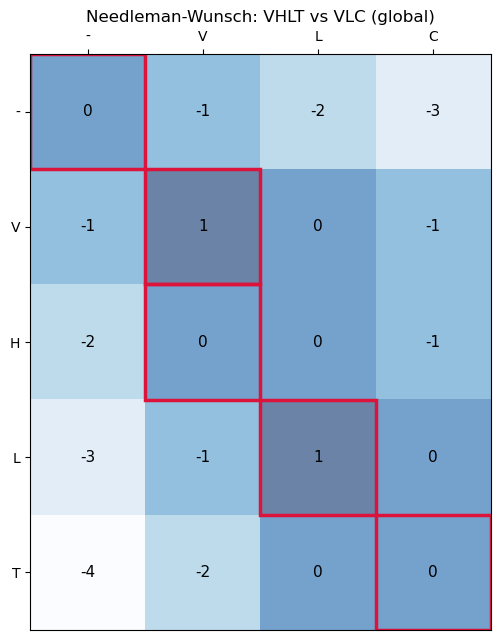

In [9]:
def plot_dp_matrix(seqA, seqB, S, trace, title, global_alignment=True):
    m, n = S.shape
    fig, ax = plt.subplots(figsize=(1.1*n + 1, 1.1*m + 1))
    ax.imshow(S, cmap="Blues", alpha=0.6)

    for i in range(m):
        for j in range(n):
            ax.text(j, i, f"{S[i,j]:.0f}", ha="center", va="center", fontsize=11)

    # highlight the traceback path
    if global_alignment:
        i, j = m - 1, n - 1
    else:
        i, j = np.unravel_index(S.argmax(), S.shape)
    path = [(i, j)]
    while (global_alignment and (i > 0 or j > 0)) or (not global_alignment and min(trace[i, j]) < 0):
        di, dj = trace[i, j]
        if di == 0 and dj == 0:
            break
        i, j = i + int(di), j + int(dj)
        path.append((i, j))
    for (pi, pj) in path:
        ax.add_patch(plt.Rectangle((pj-0.5, pi-0.5), 1, 1, fill=False, edgecolor="crimson", linewidth=2.5))

    ax.set_xticks(range(n)); ax.set_xticklabels(list("-" + seqB))
    ax.set_yticks(range(m)); ax.set_yticklabels(list("-" + seqA))
    ax.set_title(title)
    ax.xaxis.tick_top()
    plt.tight_layout()
    plt.show()

plot_dp_matrix(seqA, seqB, S, trace, "Needleman-Wunsch: VHLT vs VLC (global)")

## Smith-Waterman (local alignment)

In [10]:
def local_align(seqA, seqB, match=1.0, mismatch=-1.0, gap=-1.0, subst_matrix=None):
    def score(a, b):
        if a == '-' or b == '-':
            return gap
        if subst_matrix is not None:
            return subst_matrix[a, b]
        return match if a == b else mismatch

    m, n = len(seqA) + 1, len(seqB) + 1
    S = np.zeros((m, n))
    trace = np.zeros((m, n, 2))

    for i in range(1, m):
        for j in range(1, n):
            diag = S[i-1, j-1] + score(seqA[i-1], seqB[j-1])
            up = S[i-1, j] + gap
            left = S[i, j-1] + gap
            S[i, j] = max(diag, up, left, 0.0)
            if S[i, j] == 0:
                trace[i, j, :] = (0, 0)
            elif diag >= max(up, left):
                trace[i, j, :] = (-1, -1)
            elif up >= left:
                trace[i, j, :] = (-1, 0)
            else:
                trace[i, j, :] = (0, -1)
    return S, trace

### Global vs. local, side by side

Two real 11-residue fragments that share one strong conserved region but differ everywhere else: `SAVTALWGKVN` from human beta-globin (HBB) and `QLVLNVWGKVE` from human myoglobin (MYG) — two paralogous globins (see Day 3/5) whose sequences have diverged overall but still share the `WGKV` motif that is part of the conserved globin fold. Global alignment is forced to account for the mismatched residues on both sides of that motif too, while local alignment finds just the strong match in the middle.

This time, instead of the flat identity scheme, both alignments below are scored with the real PAM250 matrix introduced above — with a correspondingly larger gap penalty ($-8$ rather than $-1$), since PAM250's match scores range far higher (up to $+17$ for `W`-`W`) than the flat $+1$ used before; a gap penalty still stuck at the old scale would make gaps effectively free.

In [11]:
seqA, seqB = "SAVTALWGKVN", "QLVLNVWGKVE"
pam_gap = -8.0

S_g, trace_g = global_align(seqA, seqB, gap=pam_gap, subst_matrix=pam250)
outA_g, outB_g = format_alignment(seqA, seqB, S_g, trace_g)
print("Global (Needleman-Wunsch), scored with PAM250:")
print(outA_g)
print(outB_g)
print("Score:", S_g[-1, -1])
print()

S_l, trace_l = local_align(seqA, seqB, gap=pam_gap, subst_matrix=pam250)
outA_l, outB_l = format_local_alignment(seqA, seqB, S_l, trace_l)
print("Local (Smith-Waterman), scored with PAM250:")
print(outA_l)
print(outB_l)
print("Score:", S_l.max())

Global (Needleman-Wunsch), scored with PAM250:
SAVTALWGKVN
QLVLNVWGKVE
Score: 33.0

Local (Smith-Waterman), scored with PAM250:
VTALWGKVN
VLNVWGKVE
Score: 36.0


### Tracing back both alignments, step by step

The same `verbose_traceback` helper works for both — for the local alignment it starts at the single highest-scoring cell instead of the bottom-right corner, and stops as soon as it reaches a zero instead of the top-left. Both calls below pass `subst_matrix=pam250`, so the diagonal/up/left candidates printed at each step are the real PAM250-scored ones, not the flat identity scheme used earlier.

In [12]:
print("Global traceback:")
print()
_ = verbose_traceback(seqA, seqB, S_g, trace_g, pam_gap, subst_matrix=pam250, global_alignment=True)

print()
print("=" * 60)
print()

print("Local traceback:")
print()
_ = verbose_traceback(seqA, seqB, S_l, trace_l, pam_gap, subst_matrix=pam250, global_alignment=False)

Global traceback:

Starting at S[11,11] = 33

Step 1: at S[11,11]  (diag=33, up=16, left=16)  ->  took diagonal: align 'N' / 'E'
Step 2: at S[10,10]  (diag=32, up=12, left=12)  ->  took diagonal: align 'V' / 'V'
Step 3: at S[9,9]  (diag=28, up=7, left=7)  ->  took diagonal: align 'K' / 'K'
Step 4: at S[8,8]  (diag=23, up=2, left=2)  ->  took diagonal: align 'G' / 'G'
Step 5: at S[7,7]  (diag=18, up=-15, left=-15)  ->  took diagonal: align 'W' / 'W'
Step 6: at S[6,6]  (diag=1, up=-15, left=-17)  ->  took diagonal: align 'L' / 'V'
Step 7: at S[5,5]  (diag=-1, up=-15, left=-16)  ->  took diagonal: align 'A' / 'N'
Step 8: at S[4,4]  (diag=-1, up=-15, left=-14)  ->  took diagonal: align 'T' / 'L'
Step 9: at S[3,3]  (diag=1, up=-17, left=-14)  ->  took diagonal: align 'V' / 'V'
Step 10: at S[2,2]  (diag=-3, up=-17, left=-16)  ->  took diagonal: align 'A' / 'L'
Step 11: at S[1,1]  (diag=-1, up=-16, left=-16)  ->  took diagonal: align 'S' / 'Q'

Reached S[0,0] = 0  -- the start of both sequenc

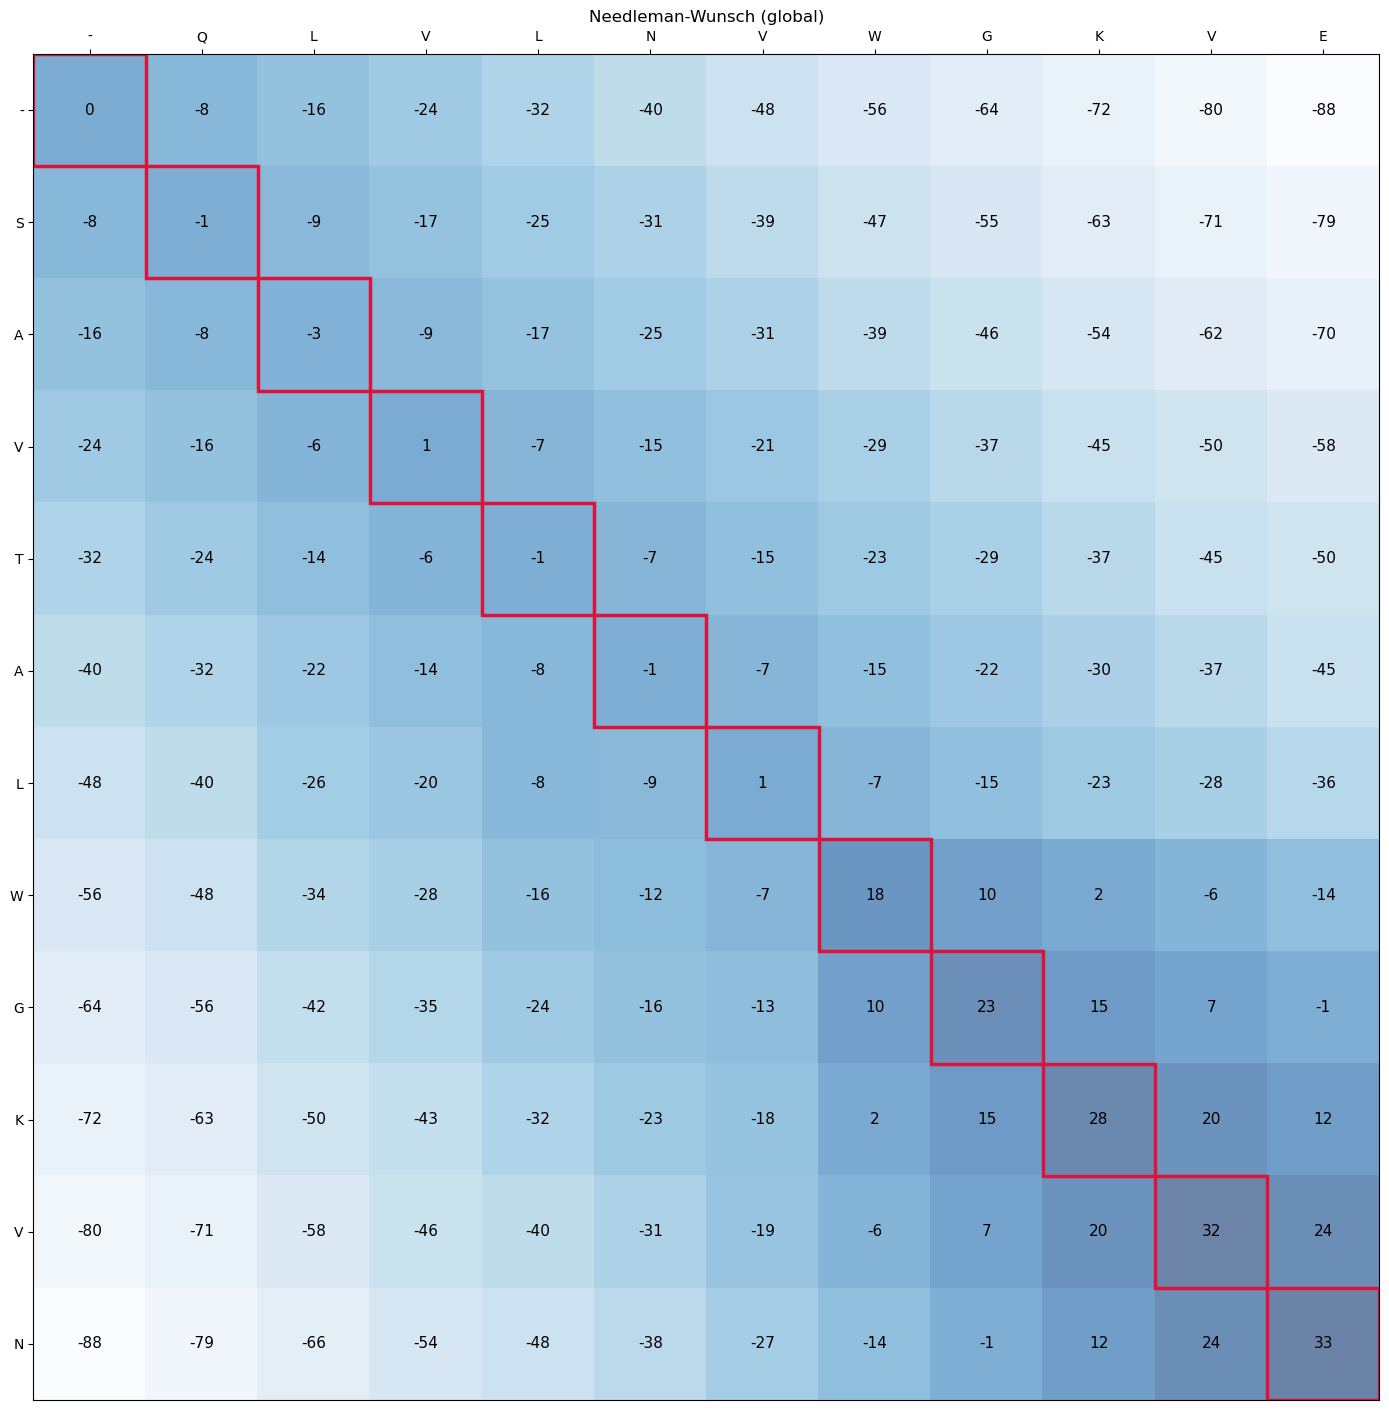

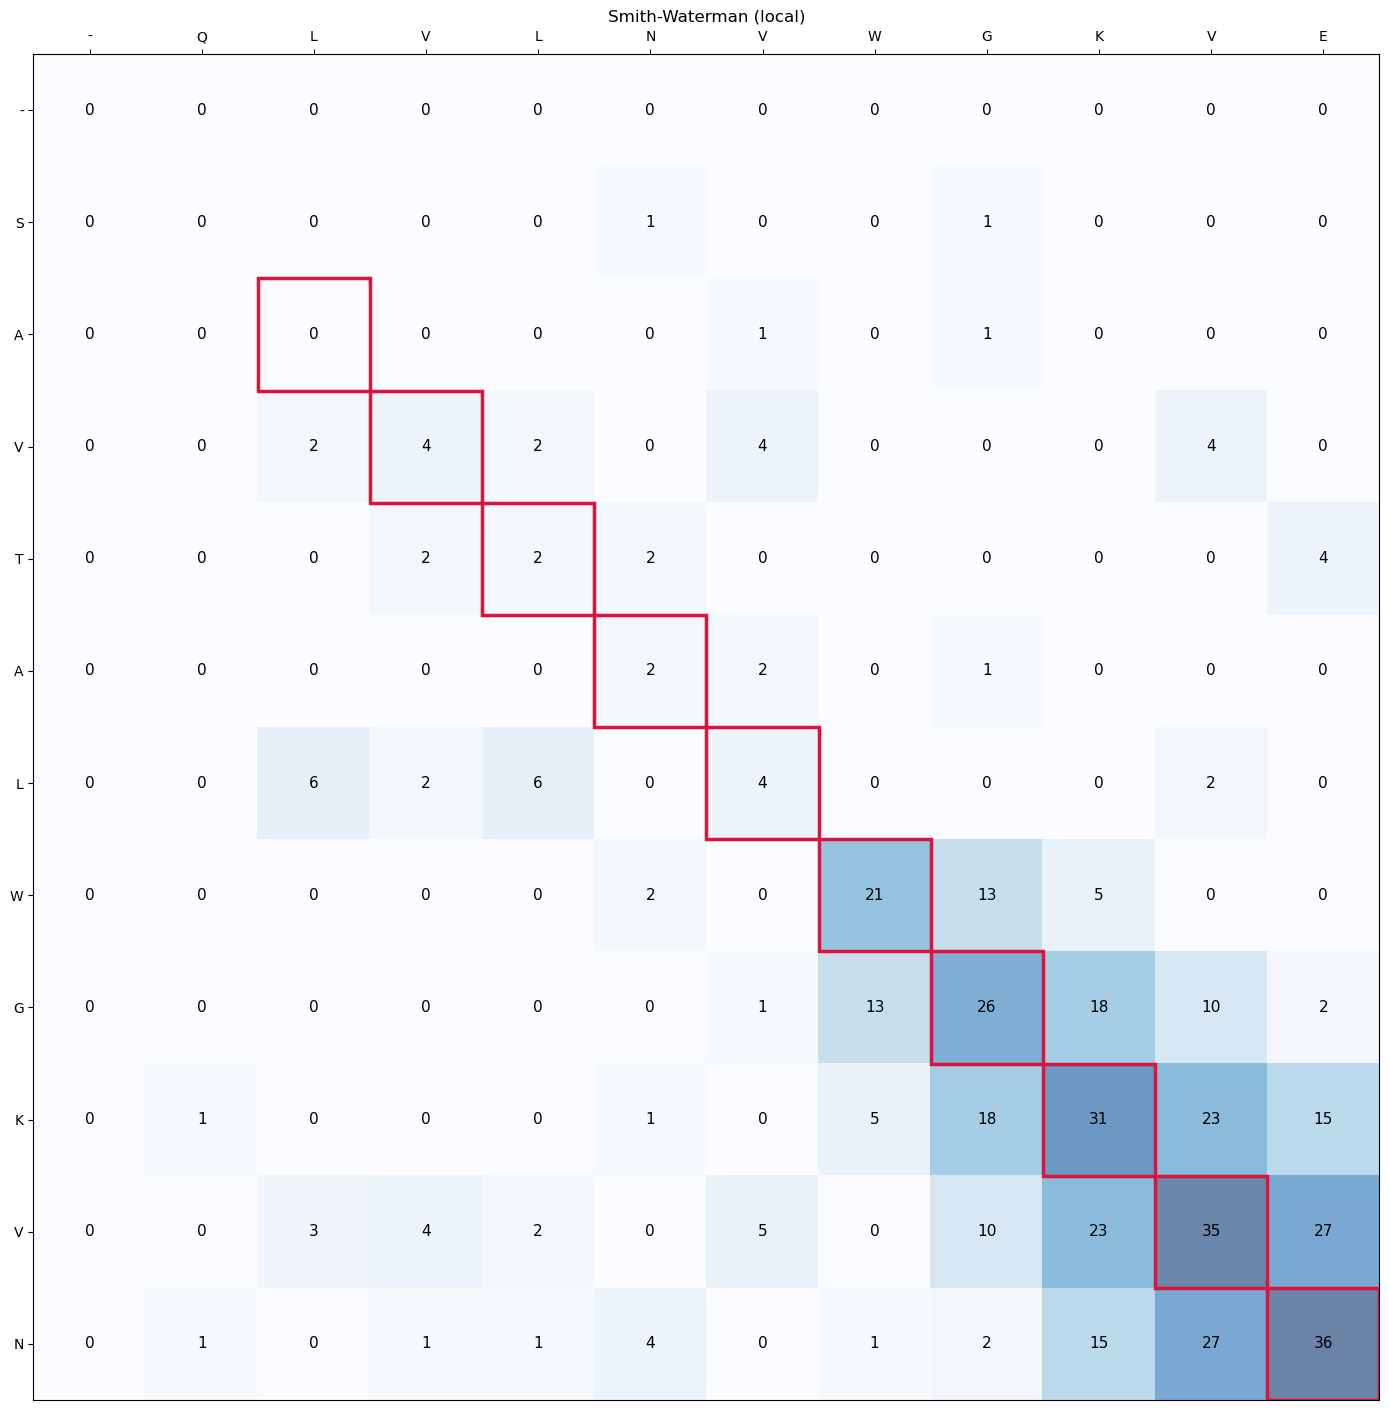

In [13]:
plot_dp_matrix(seqA, seqB, S_g, trace_g, "Needleman-Wunsch (global)", global_alignment=True)
plot_dp_matrix(seqA, seqB, S_l, trace_l, "Smith-Waterman (local)", global_alignment=False)

Notice how the local alignment's matrix has no negative numbers (any candidate score below zero is reset to zero, per Smith-Waterman's rule), and its traceback path is short — it starts at the single highest-scoring cell and stops as soon as it hits a zero, rather than being forced all the way to a corner. That's exactly the mechanical difference described on the Day 4 page, now visible directly in the matrix.

Also notice that with PAM250, the local alignment's matched core is longer than just the `WGKV` motif found earlier under the flat identity scheme — it extends to include neighbouring positions like `L`-`V` ($+2$, a mild hydrophobic substitution) and `T`-`L` ($-2$, mildly unfavourable but not disqualifying) that a flat $-1$ mismatch penalty would have made too costly to keep. A real substitution matrix lets the alignment "see" that some substitutions are almost free biologically, so the true similarity block can extend further than strict identity scoring would allow.

## Try it yourself

Change `seqA`/`seqB` above to your own sequences, or change the match/mismatch/gap scores, and re-run — in particular, try making the gap penalty very large or very small and see how that changes which alignment wins. You can also swap `pam250` for another real matrix from Biopython's collection, e.g. `substitution_matrices.load("BLOSUM62")`, and see how the alignment and its score change.